# **_机器翻译_**


# 0. 要解决的问题


① 你将建立一个神经机器翻译（NMT）模型，以将人类可读的日期（"25th of June, 2009"）转换为机器可读的日期（"2009-06-25"）。

② 你将使用注意力模型来完成此任务，注意力模型是序列模型中最复杂的序列之一。


# 1. 导入库


In [1]:
from keras.layers import Bidirectional, Concatenate, Permute, Dot, Input, LSTM, Multiply
from keras.layers import RepeatVector, Dense, Activation, Lambda
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.models import load_model, Model
import keras.backend as K
import numpy as np

from faker import Faker
import random
from tqdm import tqdm
from babel.dates import format_date
from andrew_dl.l5.l5w3a.nmt_utils import *
import matplotlib.pyplot as plt

%matplotlib inline

# 2. 日期转换


① 你在此处构建的模型可用于将一种语言翻译成另一种语言，例如从英语翻译成印地语。

② 但是，语言翻译需要大量的数据集，通常需要花费数天时间在 GPU 上进行训练。

③ 为了给你提供一个即使不使用大量数据集也可以试验这些模型的地方，我们将使用更简单的“日期转换”任务。


① 网络将以各种可能的格式输入日期（例如 "the 29th of August 1958", "03/30/1968", "24 JUNE 1987"），并将其转换为标准化的机器可读日期（例如"1958-08-29", "1968-03-30", "1987-06-24"）。

② 我们将让网络学习如何以通用的机器可读格式 YYYY-MM-DD 输出日期。

③ 查看 nmtutils.py 以查看所有格式。计算并弄清楚格式如何工作，之后你将需要应用这些知识。


# 3. 数据集


① 我们将在 10000 个人类可读日期及其等效的标准化机器可读日期的数据集上训练模型。

② 让我们运行以下单元格以加载数据集并打印一些示例。


In [2]:
m = 10000
dataset, human_vocab, machine_vocab, inv_machine_vocab = load_dataset(m)

100%|██████████| 10000/10000 [00:00<00:00, 44391.92it/s]


In [3]:
dataset[:10]

[('15 dec 2022', '2022-12-15'),
 ('29.12.99', '1999-12-29'),
 ('12/14/77', '1977-12-14'),
 ('monday july 6 1970', '1970-07-06'),
 ('tuesday march 2 1976', '1976-03-02'),
 ('sunday december 1 2024', '2024-12-01'),
 ('saturday august 15 2009', '2009-08-15'),
 ('18 may 1972', '1972-05-18'),
 ('13 sep 2015', '2015-09-13'),
 ('wednesday march 1 2017', '2017-03-01')]

In [4]:
for k, v in list(human_vocab.items())[:50]:
    print(k, v)

  0
. 1
/ 2
0 3
1 4
2 5
3 6
4 7
5 8
6 9
7 10
8 11
9 12
a 13
b 14
c 15
d 16
e 17
f 18
g 19
h 20
i 21
j 22
l 23
m 24
n 25
o 26
p 27
r 28
s 29
t 30
u 31
v 32
w 33
y 34
<unk> 35
<pad> 36


In [5]:
len(machine_vocab)

11

③ 你已加载：

- dataset ：（人可读日期，机器可读日期）元组列表
- human_vocab：python 字典，将人类可读日期中使用的所有字符映射到整数索引
- machine_vocab：python 字典，将机器可读日期中使用的所有字符映射到整数索引。这些索引不一定与 human_vocab 一致。
- inv_machine_vocab：machine_vocab 的逆字典，从索引映射回字符。

④ 让我们预处理数据并将原始文本数据映射到索引值。

⑤ 我们还将使用 Tx = 30（我们假设这是人类可读日期的最大长度；如果输入的时间更长，则必须截断它）和 Ty = 10（因为“YYYY-MM-DD”为 10 个长字符）。


In [6]:
Tx = 30
Ty = 10
X, Y, Xoh, Yoh = preprocess_data(dataset, human_vocab, machine_vocab, Tx, Ty)

print("X.shape:", X.shape)
print("Y.shape:", Y.shape)
print("Xoh.shape:", Xoh.shape)
print("Yoh.shape:", Yoh.shape)

X.shape: (10000, 30)
Y.shape: (10000, 10)
Xoh.shape: (10000, 30, 37)
Yoh.shape: (10000, 10, 11)


① 你现在拥有：

- X：训练集中人类可读日期的处理版本，其中每个字符都由通过 human_vocab 映射到该字符的索引替换。每个日期都用特殊字符（<pad>）进一步填充为
  值。X.shape = (m, Tx)
- Y：训练集中机器可读日期的处理版本，其中每个字符都被映射为 machine_vocab 中映射到的索引替换。你应该具有 Y.shape = (m, Ty)。
- Xoh：X 的一个独热版本，由于 human_vocab，将“1”条目的索引映射到该字符。Xoh.shape = (m, Tx, len(human_vocab))
- Yoh：Y 的一个独热版本，由于使用 machine_vocab，因此将“1”条目的索引映射到了该字符。Yoh.shape = (m, Tx, len(machine_vocab))在这里，因为有 11 个字符（“-”以及 0-9），所以 len(machine_vocab) = 11。

② 我们再看一些预处理训练集的示例。你可以在下面的单元格中随意使用 index 来查看数据集，并查看如何对 source/target 日期进行预处理。


In [7]:
print(Xoh)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 1. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]
  [0. 0. 0. ... 0. 0. 1.]]]


In [8]:
index = 0
print("Source date:", dataset[index][0])
print("Target date:", dataset[index][1])
print()
print("Source after preprocessing (indices):", X[index])
print("Target after preprocessing (indices):", Y[index])
print(X[index].shape)
print(Y[index].shape)
print(Xoh[index].shape)
print(Yoh[index].shape)
print("Source after preprocessing (one-hot):", Xoh[index])
print("Target after preprocessing (one-hot):", Yoh[index])

Source date: 15 dec 2022
Target date: 2022-12-15

Source after preprocessing (indices): [ 4  8  0 16 17 15  0  5  3  5  5 36 36 36 36 36 36 36 36 36 36 36 36 36
 36 36 36 36 36 36]
Target after preprocessing (indices): [3 1 3 3 0 2 3 0 2 6]
(30,)
(10,)
(30, 37)
(10, 11)
Source after preprocessing (one-hot): [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]
Target after preprocessing (one-hot): [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


# 4. 注意力机制


① 如果你必须将一本书的段落从法语翻译为英语，则无需阅读整个段落然后关闭该书并进行翻译。

② 即使在翻译过程中，你也会阅读/重新阅读并专注于与你所写下的英语部分相对应的法语段落部分。

③ 注意机制告诉神经机器翻译模型在任何步骤都应该注意到的地方。


① 在这一部分中，你将实现讲座视频中介绍的注意力机制。

② 这是一个提醒你该模型如何工作的图。

③ 左图显示了注意力模型。右图显示了“注意”步骤用于计算注意变量$\alpha^{\langle t, t' \rangle}$，这些变量用于计算上下文变量$context^{\langle t \rangle}$输出中的每个时间步长($t=1, \ldots, T_y$)。

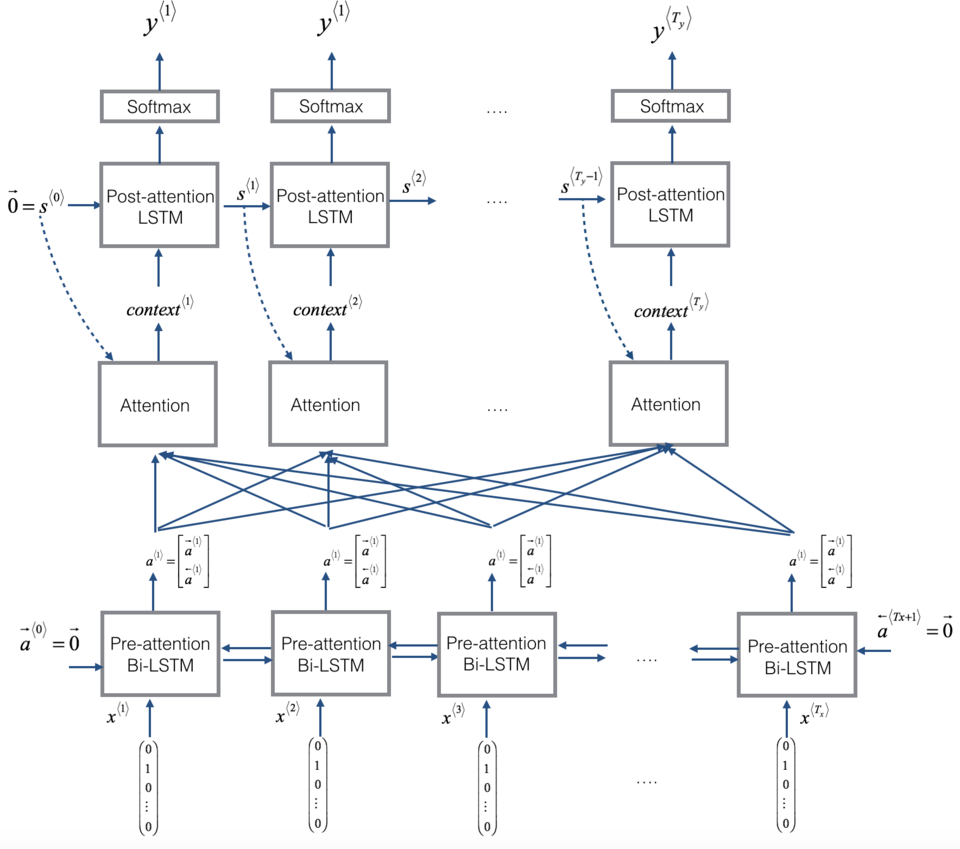

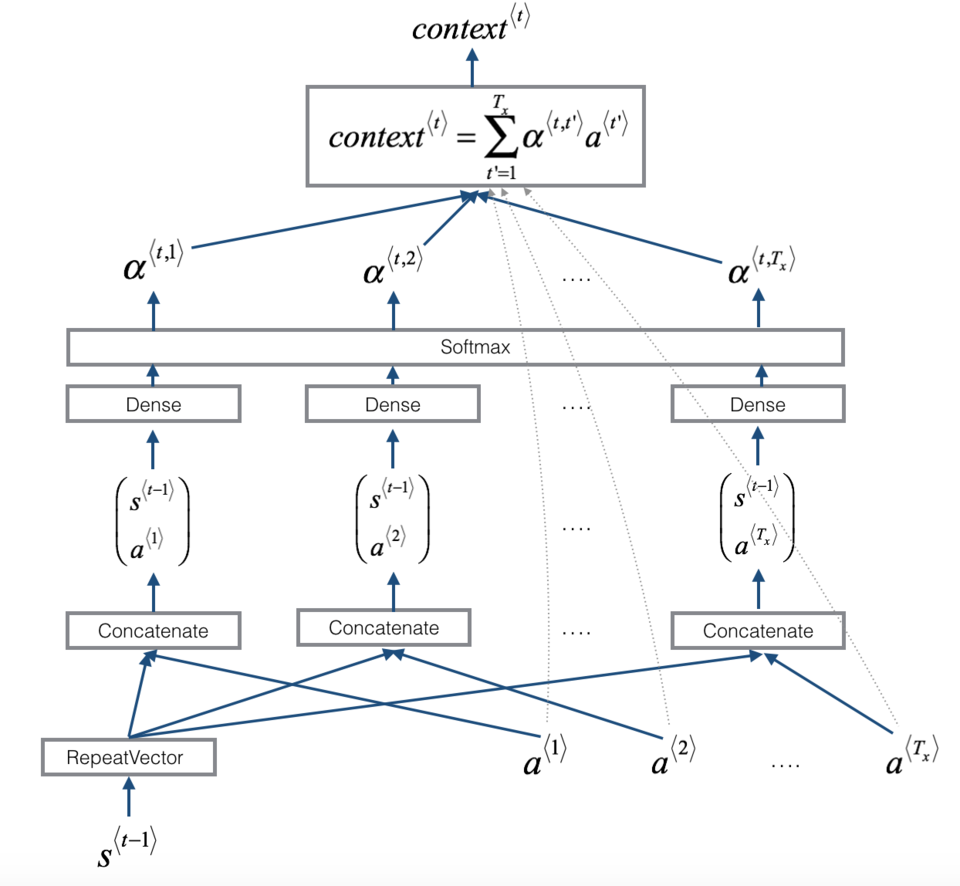

<center>图1：带注意力机制的神经机器翻译</center>


④ 你可能会注意到以下一些模型属性：

- 此模型中有两个单独的 LSTM（请参见左侧的图）。

  - 因为图片底部的一个是双向 LSTM，并且在“注意力机制”之前出现，所以我们将其称为 pre-attention Bi-LSTM。
  - 图表顶部的 LSTM 在注意力机制之后，因此我们将其称为 post-attention LSTM。
  - pre-attention Bi-LSTM 经过$T_x$个时间步长；post-attention LSTM 经过$T_y$个时间步长。

- post-attention LSTM 从一个时间步长传递到下一个步长，传递$s^{\langle t \rangle}, c^{\langle t \rangle}$。

  - 在讲座视频中，我们仅将基本 RNN 用于激活后序列模型，因此 RNN 输出激活捕获的状态$s^{\langle t\rangle}$。
  - 但是，由于我们在这里使用 LSTM，因此 LSTM 既具有输出激活$s^{\langle t\rangle}$，也具有隐藏单元状态$c^{\langle t\rangle}$。
  - 但是，与先前的文本生成示例（例如第 1 周的恐龙）不同，在此模型中，时间$t$的激活后 LSTM 不会将特定的生成的$y^{\langle t-1 \rangle}$作为输入只需将$s^{\langle t\rangle}$和$c^{\langle t\rangle}$作为输入。
  - 我们以这种方式设计了模型，因为（与相邻字符高度相关的语言生成不同），在 YYYY-MM-DD 日期中，上一个字符与下一个字符之间没有那么强的依赖性。

- 我们使用$a^{\langle t \rangle} = [\overrightarrow{a}^{\langle t \rangle}; \overleftarrow{a}^{\langle t \rangle}]$表示 pre-attention Bi-LSTM 的正向和反向激活的串联。

- 右图使用 RepeatVector 节点复制$s^{\langle t-1 \rangle}$的值$T_x$次，然后使用 Concatenation 来连接$s^{\langle t-1 \rangle}$和$a^{\langle t \rangle}$来计算$e^{\langle t, t'}$，然后将其传递给 softmax 以计算$\alpha^{\langle t, t' \rangle}$。
  - 我们将在下面的 Keras 中说明如何使用 RepeatVector 和 Concatenation。


① 让我们实现这个模型。你将从实现 one_step_attention() 和 model()两个函数开始：

1）one*step_attention()：在步骤$t$中，给出 Bi-LSTM 的所有隐藏状态$([a^{<1>},a^{<2>}, ..., a^{<Tx>}])$和第二个的先前隐藏状态$s^{<t-1>}$)，one_step_attention()将计算注意力权重$([\alpha^{t,1},\alpha^{t,2}, ..., \alpha^{t,Tx}])$并输出上下文向量：$$context^{} = \sum*{t' = 0}^{T_x} \alpha^{t,t'}a^{t'}\tag{1}$$

- 请注意，我们在此笔记本中将注意力表示为$context^{\langle t \rangle}$。在讲座视频中，上下文被表示为$c^{\langle t \rangle}$，但在这里我们将其称为$context^{\langle t \rangle}$，以避免与(post-attention)LSTM 内部记忆单元变量混淆，有时也称为$c^{\langle t \rangle}$。

2）model()：实现整个模型。它首先通过 Bi-LSTM 运行输入以获取$[a^{<1>},a^{<2>}, ..., a^{<Tx>}]$。然后，它调用 one_step_attention()$T_y$次（“for”循环）。在此循环的每次迭代中，它将计算出上下文向量$c^{<t>}$给第二个 LSTM, 根据 LSTM 的输出，运行 softmax 激活的全连接层以生成预测$\hat{y}^{<t>}$。

② 练习：实现 one_step_attention()。函数 model()将使用 for 循环调用 one_step_attention()$T_y$中的层，重要的是所有$T_y$副本具有相同的权重。即，它不应该每次都重新初始化权重。换句话说，所有$T_y$步骤均应具有权重。这是在 Keras 中实现可共享权重的层的方法：

1. 定义层对象（例如，作为全局变量）。
2. 在传播输入时调用这些对象。


In [9]:
# 将共享层定义为全局变量
# RepeatVector 是 Keras 中的一个层，用于将输入重复指定的次数。这里 Tx 应该是一个整数，表示重复的次数。例如，如果输入是一个形状为 (batch_size, n) 的张量，经过 RepeatVector(Tx) 层后，输出的形状将变为 (batch_size, Tx, n)。
# 用途：在注意力机制中，通常用于将某个向量重复多次，以便与其他序列进行拼接操作。
repeator = RepeatVector(Tx)
# Concatenate 层用于将多个张量在指定的轴上进行拼接。axis=-1 表示在最后一个轴上进行拼接。例如，如果有两个形状分别为 (batch_size, m, n1) 和 (batch_size, m, n2) 的张量，经过 Concatenate(axis=-1) 层后，输出的形状将变为 (batch_size, m, n1 + n2)。
# 用途：在注意力机制中，常用于将不同的特征向量拼接在一起，以便后续进行计算。
concatenator = Concatenate(axis=-1)
# Dense 层是全连接层，将输入的每个神经元与输出的每个神经元都进行连接。这里 10 表示输出的维度，activation="tanh" 表示使用双曲正切函数作为激活函数。
# 用途：在注意力机制中，用于对输入的特征进行非线性变换，增加模型的表达能力。
densor1 = Dense(10, activation="tanh")
# 同样是全连接层，输出维度为 1，使用 ReLU（Rectified Linear Unit）作为激活函数。
# 用途：通常用于计算注意力权重的中间步骤。
densor2 = Dense(1, activation="relu")
# 在这个 notebook 我们正在使用自定义的 softmax(axis = 1)
# Activation 层用于对输入应用指定的激活函数。这里使用自定义的 softmax 函数，将输入转换为概率分布，通常用于计算注意力权重。
# 用途：在注意力机制中，将计算得到的得分转换为注意力权重。
activator = Activation(softmax, name='attention_weights')
# Dot 层用于对两个张量进行点积运算。axes=1 表示在第一个轴上进行点积。例如，如果有两个形状分别为 (batch_size, m, n) 和 (batch_size, n, p) 的张量，经过 Dot(axes=1) 层后，输出的形状将变为 (batch_size, m, p)。
# 用途：在注意力机制中，用于将注意力权重与相应的特征向量进行加权求和。
dotor = Dot(axes=1)

③ 现在你可以使用这些层来实现 one_step_attention()。 为了通过这些层之一传播 Keras 张量对象 X，请使用 layer（X）（如果需要多个输入则使用 layer（[X，Y]））。densor(X)将通过上面定义的 Dense(1) 层传播 X。


In [10]:
# GRADED FUNCTION: one_step_attention
def one_step_attention(a, s_prev):
    """
    执行一步 attention: 输出一个上下文向量，输出作为注意力权重的点积计算的上下文向量
    "alphas"  Bi-LSTM的 隐藏状态 "a"
    参数：
    a --  Bi-LSTM的输出隐藏状态 numpy-array 维度 (m, Tx, 2*n_a)
    s_prev -- (post-attention) LSTM的前一个隐藏状态, numpy-array 维度(m, n_s)
    返回：
    context -- 上下文向量, 下一个(post-attetion) LSTM 单元的输入
    """
    # a：Bi - LSTM 的输出隐藏状态，是一个 numpy 数组，维度为 (m, Tx, 2*n_a)。其中，m 是批量大小（batch size），Tx 是输入序列的长度，2*n_a 是 Bi - LSTM 隐藏状态的维度（因为是双向的，所以是单向隐藏状态维度 n_a 的两倍）。
# s_prev：（post - attention）LSTM 的前一个隐藏状态，是一个 numpy 数组，维度为 (m, n_s)，其中 n_s 是（post - attention）LSTM 隐藏状态的维度
    # 使用 repeator 重复 s_prev 维度 (m, Tx, n_s) 这样你就可以将它与所有隐藏状态"a" 连接起来。 (≈ 1 line)
    # 使用之前定义的 RepeatVector 层 repeator 将 s_prev 重复 Tx 次，使其维度变为 (m, Tx, n_s)，这样就可以与 a 进行拼接操作。
    s_prev = repeator(s_prev)
    # 使用 concatenator 在最后一个轴上连接 a 和 s_prev (≈ 1 line)
    # 使用 Concatenate 层 concatenator 在最后一个轴上（axis=-1）将 a 和重复后的 s_prev 进行拼接，得到一个新的张量 concat，其维度为 (m, Tx, 2*n_a + n_s)。
    concat = concatenator([a, s_prev])
    # 使用 densor1 传入参数 concat, 通过一个小的全连接神经网络来计算“中间能量”变量 e。(≈1 lines)
    # 将拼接后的张量 concat 输入到第一个全连接层 densor1 中，该层有 10 个神经元，激活函数为 tanh，用于对输入进行非线性变换，得到 “中间能量” 变量 e。
    e = densor1(concat)
    # 使用 densor2 传入参数 e , 通过一个小的全连接神经网络来计算“能量”变量 energies。(≈1 lines)
    # 将 “中间能量” 变量 e 输入到第二个全连接层 densor2 中，该层有 1 个神经元，激活函数为 relu，得到 “能量” 变量 energies，其维度为 (m, Tx, 1)。
    energies = densor2(e)
    # 使用 activator 传入参数 "energies" 计算注意力权重 "alphas" (≈ 1 line)
    # 将 “能量” 变量 energies 输入到 Activation 层 activator 中，使用自定义的 softmax 函数将其转换为注意力权重 alphas，其维度为 (m, Tx, 1)，且每个样本的 Tx 个注意力权重之和为 1
    alphas = activator(energies)
    # 使用 dotor 传入参数 "alphas" 和 "a" 计算下一个（(post-attention) LSTM 单元的上下文向量 (≈ 1 line)
    # 使用 Dot 层 dotor 对注意力权重 alphas 和 Bi - LSTM 的隐藏状态 a 进行点积运算，得到上下文向量 context，其维度为 (m, 1, 2*n_a)
    context = dotor([alphas, a])
    return context

① 在对 model()函数进行编码之后，你将能够检查 one_step_attention()的预期输出。

② 练习：按照图 2 和上面的文字中的说明实现 model()。同样，我们定义了全局层，这些全局层将共享将在 model()中使用的权重。


In [11]:
# n_a：通常代表双向长短期记忆网络（Bi - LSTM）中每个方向的隐藏单元数量。由于是双向的，所以 Bi - LSTM 最终输出的隐藏状态维度是 2 * n_a。这里 n_a = 32，意味着双向 Bi - LSTM 输出的隐藏状态维度是 64。
# n_s：表示后注意力（post - attention）LSTM 单元的隐藏单元数量。在注意力机制的模型中，后注意力 LSTM 会接收上下文向量作为输入，这里 n_s = 64 表示该 LSTM 单元的隐藏状态维度为 64
n_a = 32
n_s = 64
# LSTM：这是 Keras 中用于构建长短期记忆网络（LSTM）层的类。LSTM 是一种特殊的循环神经网络（RNN），能够处理序列数据中的长期依赖关系。
# n_s：作为参数传入 LSTM 类，指定了 LSTM 单元的隐藏单元数量，也就是输出的隐藏状态的维度。
# return_state=True：这个参数设置为 True 表示该 LSTM 层不仅会返回输出序列，还会返回最后一个时间步的隐藏状态和细胞状态。在后续的模型构建中，可能会用到这些状态信息
post_activation_LSTM_cell = LSTM(n_s, return_state=True)
# Dense：这是 Keras 中用于构建全连接层的类。全连接层会将输入的每个神经元与输出的每个神经元都进行连接。
# len(machine_vocab)：作为参数传入 Dense 类，指定了输出层的神经元数量。machine_vocab 通常是目标语言（机器语言）的词汇表，len(machine_vocab) 表示词汇表的大小，也就是模型需要预测的类别数量。
# activation=softmax：指定了输出层的激活函数为 softmax。softmax 函数会将输出层的每个神经元的值转换为概率值，并且所有概率值之和为 1，常用于多分类问题中，使得模型输出每个类别的预测概率。
output_layer = Dense(len(machine_vocab), activation=softmax)

③ 现在你可以在 for 循环中使用这些层$T_y$次来生成输出，并且它们的参数将不会重新初始化。你将必须执行以下步骤：

1.  将输入传播到 Bidirectional LSTM
2.  迭代$t = 0, \dots, T_y-1$：
    - 在$[\alpha^{<t,1>},\alpha^{<t,2>}, ..., \alpha^{<t,Tx>}]和s^{<t-1>}$上调用 one_step_attention() 以获取上下文向量$context^{<t>}$。
    - 将$context^{<t>}$分配给 post-attention LSTM 单元。请记住，使用 initial_state= [previous hidden state, previous cell state]传递此 LSTM 的前一个隐藏状态$s^{<t-1>}$和单元状态$c^{<t-1>}$。取回新的隐藏状态$s^{<t>}和新的单元状态c^{<t>}$。
    - 将 softmax 层应用于$s^{<t>}$，获得输出。
    - 通过将输出添加到输出列表中来保存输出。
3.  创建你的 Keras 模型实例，它应该具有三个输入("inputs",$s^{<0>}$and$c^{<0>}$)并输出"outputs"列表。


In [12]:
def model(Tx, Ty, n_a, n_s, human_vocab_size, machine_vocab_size):
    """
    参数:
    Tx -- 输入序列的长度
    Ty -- 输出序列的长度
    n_a -- Bi-LSTM的隐藏状态大小
    n_s -- post-attention LSTM的隐藏状态大小
    human_vocab_size -- python字典 "human_vocab" 的大小
    machine_vocab_size -- python字典 "machine_vocab" 的大小
    返回：
    model -- Keras 模型实例
    """
    # 定义模型的输入，维度 (Tx,)
    # 定义 s0 和 c0, 初始化解码器 LSTM 的隐藏状态，维度 (n_s,)
    X = Input(shape=(Tx, human_vocab_size))
    s0 = Input(shape=(n_s,), name='s0')
    c0 = Input(shape=(n_s,), name='c0')
    s = s0
    c = c0
    # 初始化一个空的输出列表
    outputs = []
    # 第一步：定义 pre-attention Bi-LSTM。 记得使用 return_sequences=True. (≈ 1 line)
    # Bidirectional(LSTM(n_a, return_sequences=True))：构建一个双向 LSTM 层，每个方向的 LSTM 单元有 n_a 个隐藏单元，return_sequences=True 表示返回每个时间步的隐藏状态。
# input_shape=(Tx, human_vocab_size)：指定输入的形状。
    a = Bidirectional(LSTM(n_a, return_sequences=True),
                      input_shape=(m, Tx, n_a * 2))(X)
    # 第二步：迭代 Ty 步
    for t in range(Ty):
        # 第二步.A: 执行一步注意机制，得到在 t 步的上下文向量 (≈ 1 line)
        context = one_step_attention(a, s)
        # 第二步.B: 使用 post-attention LSTM 单元得到新的 "context"
        # 别忘了使用： initial_state = [hidden state, cell state] (≈ 1 line)
        # 将上下文向量 context 输入到后注意力 LSTM 单元 post_activation_LSTM_cell 中，更新隐藏状态 s 和细胞状态 c。
        s, _, c = post_activation_LSTM_cell(context, initial_state=[s, c])
        # 第二步.C: 使用全连接层处理post-attention LSTM 的隐藏状态输出 (≈ 1 line)
        out = output_layer(s)
        # 第二步.D: 追加 "out" 到 "outputs" 列表 (≈ 1 line)
        outputs.append(out)
    # 第三步：创建模型实例，获取三个输入并返回输出列表。 (≈ 1 line)
    model = Model(inputs=[X, s0, c0], outputs=outputs)
    return model

In [13]:
# 运行以下单元以创建模型
model = model(Tx, Ty, n_a, n_s, len(human_vocab), len(machine_vocab))

In [14]:
# 让我们查看模型的摘要，以检查它是否与预期输出相匹配
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 30, 37)]     0           []                               
                                                                                                  
 s0 (InputLayer)                [(None, 64)]         0           []                               
                                                                                                  
 bidirectional (Bidirectional)  (None, 30, 64)       17920       ['input_1[0][0]']                
                                                                                                  
 repeat_vector (RepeatVector)   (None, 30, 64)       0           ['s0[0][0]',                     
                                                                  'lstm[0][0]',               

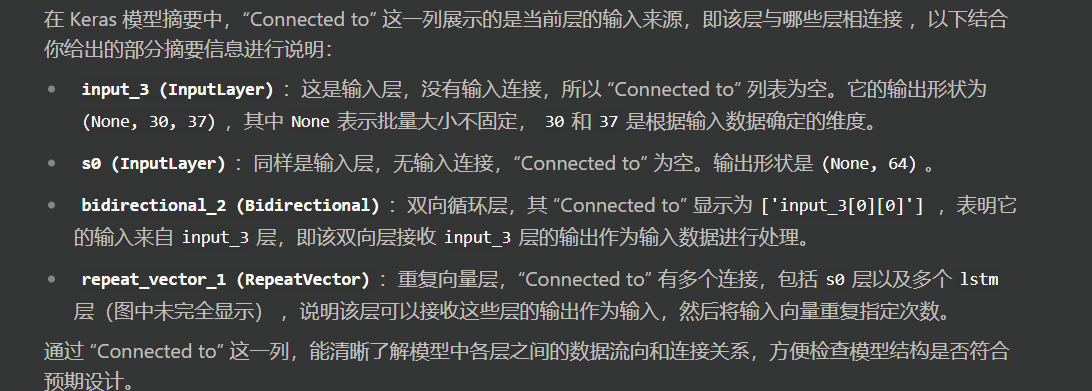


① 与往常一样，在 Keras 中创建模型后，你需要对其进行编译并定义要使用的损失，优化器和评价指标。 使用 categorical_crossentropy 损失，自定义 Adam optimizer(learning rate = 0.005,$\beta_1 = 0.9$,$\beta_2 = 0.999$, decay = 0.01)和['accuracy']指标：


In [15]:
# START CODE HERE ### (≈2 lines)
opt = Adam(lr=0.005, beta_1=0.9, beta_2=0.999, decay=0.01)
model.compile(loss='categorical_crossentropy',
              optimizer=opt, metrics=['accuracy'])
### END CODE HERE ###

d:\miniforge3\envs\v3.10.13\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


② 最后一步是定义所有输入和输出以适合模型：

- 你已经拥有包含训练示例的维度为$(m = 10000, T_x = 30)$的 X。
- 你需要创建 s0 和 c0 以将你的 post_activation_LSTM_cell 初始化为 0。
- 根据你编码的 model()，你需要"outputs"作为 11 个维度元素（m，T_y）的列表。因此：outputs[i][0], ..., outputs[i][Ty]代表与$i^{th}$训练示例(X[i])。更一般而言， outputs[i][j] 是$i^{th}$训练示例中$j^{th}$字符的真实标签。


In [16]:
s0 = np.zeros((m, n_s))
c0 = np.zeros((m, n_s))
# Yoh 应该是一个 numpy 数组，swapaxes 是 numpy 数组的方法，用于交换数组的两个轴。这里 swapaxes(0, 1) 表示将数组 Yoh 的第 0 轴和第 1 轴进行交换。例如，如果 Yoh 原本形状是 (a, b) ，交换后形状变为 (b, a) 。这里 Yoh 的原始形状是 (m, Ty, len(machine_vocab)) ，交换后形状变为 (Ty, m, len(machine_vocab))。
outputs = list(Yoh.swapaxes(0, 1))

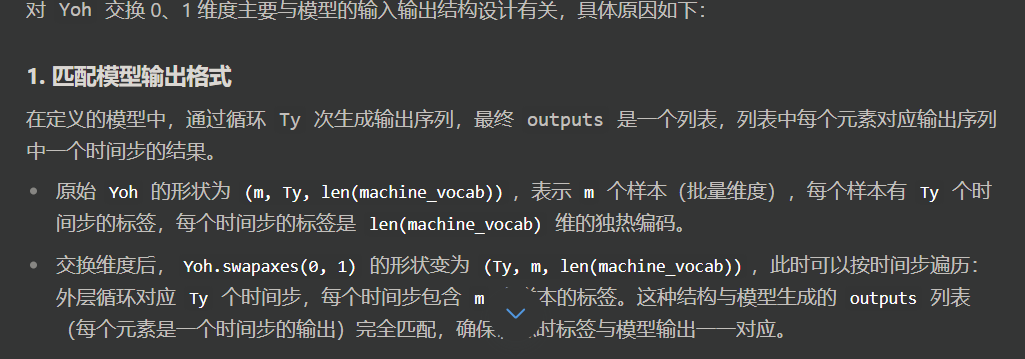


In [19]:
# 现在让我们拟合模型并运行一个epoch
model.fit([Xoh, s0, c0], outputs, epochs=1, batch_size=100)

100/100 [==============================] - 5s 46ms/step - loss: 0.7755 - dense_2_loss: 0.0183 - dense_2_1_loss: 0.0164 - dense_2_2_loss: 0.0990 - dense_2_3_loss: 0.1086 - dense_2_4_loss: 0.0039 - dense_2_5_loss: 0.0500 - dense_2_6_loss: 0.0678 - dense_2_7_loss: 0.0071 - dense_2_8_loss: 0.2351 - dense_2_9_loss: 0.1694 - dense_2_accuracy: 0.9937 - dense_2_1_accuracy: 0.9959 - dense_2_2_accuracy: 0.9775 - dense_2_3_accuracy: 0.9755 - dense_2_4_accuracy: 0.9992 - dense_2_5_accuracy: 0.9861 - dense_2_6_accuracy: 0.9843 - dense_2_7_accuracy: 0.9990 - dense_2_8_accuracy: 0.9507 - dense_2_9_accuracy: 0.9638


① 训练时，你可以看到输出的 10 个位置中的每个位置的损失以及准确性。下表为你提供了一个示例，说明该批次有 2 个示例时的精确度：

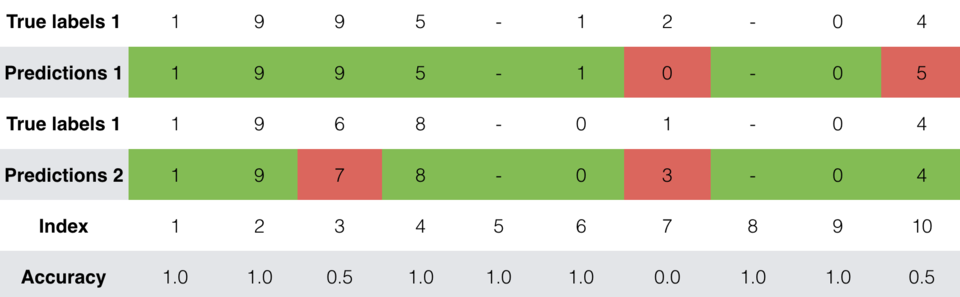

② 因此，dense_2_acc_8: 0.89 意味着你在当前数据批次中有 89％的时间正确预测了输出的第 7 个字符。

③ 我们对该模型运行了更长的时间，并保存了权重。运行下一个单元格以加载我们的权重。（通过训练模型几分钟，你应该可以获得准确度相似的模型，但是加载我们的模型可以节省你的时间。）


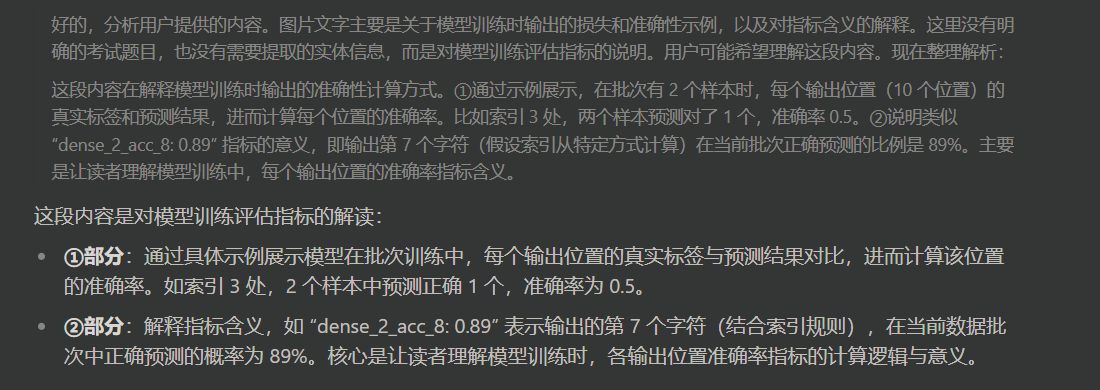


In [18]:
model.load_weights('andrew_dl/l5/l5w3a/model.h5')

④ 现在，你可以在新示例中查看结果。


In [20]:
EXAMPLES = ['3 May 1979', '5 April 09', '21th of August 2016', 'Tue 10 Jul 2007',
            'Saturday May 9 2018', 'March 3 2001', 'March 3rd 2001', '1 March 2001']
for example in EXAMPLES:
    source = string_to_int(example, Tx, human_vocab)
    source = np.array(
        list(map(lambda x: to_categorical(x, num_classes=len(human_vocab)), source)))
    source = np.expand_dims(source, axis=0)
    prediction = model.predict([source, s0, c0])
    prediction = np.argmax(prediction, axis=-1)
    output = [inv_machine_vocab[int(i)] for i in prediction]
    print("source:", example)
    print("output:", ''.join(output))

ValueError: Data cardinality is ambiguous:
  x sizes: 1, 10000, 10000
Make sure all arrays contain the same number of samples.

⑤ 你也可以更改这些示例，以使用自己的示例进行测试。

⑥ 下一部分将使你更好地了解注意力机制的作用-即生成特定输出字符时网络要注意的输入部分。


# 5. 可视化注意力


① 由于问题的输出长度固定为 10，因此还可以使用 10 个不同的 softmax 单元来执行此任务，以生成 10 个字符的输出。但是注意力模型的一个优点是输出的每个部分（例如月份）都知道它只需要依赖输入的一小部分（输入中代表月份的字符）。

② 我们可以可视化输出的哪一部分正在查看输入的哪一部分。

③ 考虑将"Saturday 9 May 2018"转换为"2018-05-09"的任务。如果我们可视化计算出的$\alpha^{\langle t, t' \rangle}$，我们将得到：

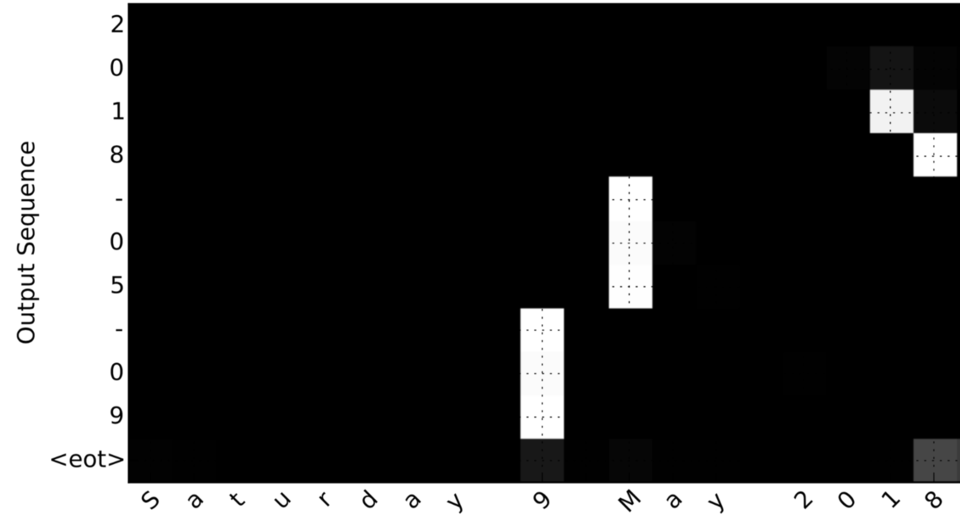

<center>图8：Full Attention Map</center>

④ 注意输出如何忽略输入的"Saturday"部分。没有一个输出时间步长关注输入的那部分。我们还看到 9 已被翻译为 09，May 已被正确翻译为 05，而输出则注意进行翻译所需的部分输入。该年份主要要求它注意输入的“18”以生成“2018”。


① 现在让我们可视化你网络中的注意力值。我们将通过网络传播一个示例，然后可视化$\alpha^{<t,t'>}$的值。

② 为了弄清注意值的位置，让我们开始打印模型摘要。


In [37]:
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 30, 37)]     0           []                               
                                                                                                  
 s0 (InputLayer)                [(None, 64)]         0           []                               
                                                                                                  
 bidirectional_2 (Bidirectional  (None, 30, 64)      17920       ['input_3[0][0]']                
 )                                                                                                
                                                                                                  
 repeat_vector_1 (RepeatVector)  (None, 30, 64)      0           ['s0[0][0]',               

③ 浏览上面的 model.summary()的输出。你可以看到，在每个时间步 dot_2 计算$t = 0, \ldots, T_y-1$上下文向量之前，名为 attention_weights 的层都会输出维度为(m, 30, 1)的 alphas。让我们从该层获取激活。

④ 函数 attention_map()从模型中提取注意力值并绘制它们。


In [39]:
attention_map = plot_attention_map(
    model, human_vocab, inv_machine_vocab, "Tuesday 09 Oct 1993", num=7, n_s=64)

ValueError: Graph disconnected: cannot obtain value for tensor KerasTensor(type_spec=TensorSpec(shape=(None, 30, 37), dtype=tf.float32, name='input_1'), name='input_1', description="created by layer 'input_1'") at layer "bidirectional". The following previous layers were accessed without issue: []

⑤ 在生成的图上，你可以观察预测输出的每个字符的注意权重值。检查此图，并检查网络对你的关注是否有意义。

⑥ 在日期转换应用程序中，你会发现大部分时间的注意力都有助于预测年份，并且对预测日期/月份没有太大影响。


① 恭喜！你已结束本作业

② 这是你在此笔记本中应记住的内容：

- 机器翻译模型可用于从一个序列映射到另一个序列。它们不仅对翻译人类语言（如法语->英语）有用，而且对日期格式翻译等任务也很有用。
- 注意机制允许网络在产生输出的特定部分时将注意力集中在输入的最相关部分。
- 使用注意力机制的网络可以将长度为$T_x$的输入转换为长度为$T_y$的输出，其中$T_x$和$T_y$可以不同。
- 你可以可视化注意权重$\alpha^{\langle t,t' \rangle}$，以查看网络在生成每个输出时要注意的内容。

③ 恭喜你完成此作业！ 现在，你可以实现注意力模型，并使用它来学习从一个序列到另一个序列的复杂映射。
